# Pha P'.0 — Ablation "dequantization" cổ điển (trước khi vào lượng tử)

Mục đích (xem `docs/NHIP2_GUIDE.md` mục 1–2): tách bạch "lợi ích từ dạng hàm
Fourier" (Schuld, Sweke & Meyer, *Phys. Rev. A* 103, 032430, 2021 — mạch
data re-uploading tương đương 1 chuỗi Fourier riêng phần của dữ liệu) khỏi
"lợi ích từ bản chất lượng tử" (entanglement, Hilbert space lớn), TRƯỚC khi
cài PennyLane/viết mạch lượng tử thật.

**Lịch sử sửa (2 lỗi thật đã tìm và sửa qua 3 vòng chạy trước):**
1. Bản đầu (`encode_w/encode_b` học được): DV-bound sụp đổ về `T=const` ngay
   epoch 1.
2. Cố định `encode_w/encode_b` (Random Fourier Features) — **vẫn sụp đổ**, kể
   cả tăng LR 50 lần, thêm EMA-correction (MINE gốc), tăng `windows_per_batch`.
3. **Tìm ra nguyên nhân THẬT (không phải bất ổn tối ưu hoá):** bản 1–2 encode
   RIÊNG từng chiều đầu vào (`y_t`, `x_lag`, `y_lag`, `mask`) rồi mới ghép
   tuyến tính ở lớp đọc ra → `T` chỉ có thể là hàm **TÁCH RỜI CỘNG TÍNH**
   `f(y_t)+g(x_lag)+h(y_lag)+k(mask)`, không có số hạng tương tác X↔Y. Chứng
   minh được bằng toán (bất đẳng thức Jensen trên phân phối marginal): với `T`
   tách rời cộng tính, giá trị tối ưu TUYỆT ĐỐI của DV bound LUÔN LÀ 0 — không
   cách train nào sửa được, vì đó là điểm tối ưu THẬT của chính lớp hàm bị hạn
   chế, không phải bẫy tối ưu hoá.
4. **Sửa đúng chỗ (bản này):** chiếu cả 4 chiều đầu vào CÙNG LÚC qua 1 ma trận
   ngẫu nhiên cố định trước khi lấy hoà âm (Random Fourier Features nhiều
   chiều, Rahimi & Recht 2007) — tạo số hạng tương tác X↔Y thật. Đã tự kiểm
   tra nhanh: DV bound giờ ước lượng được giá trị DƯƠNG có nghĩa (+0.028 ở quy
   mô nhỏ), TE ước lượng biến động thật theo cửa sổ (không còn hằng số) —
   **không cần EMA correction hay batch lớn nữa**, dùng lại đúng cấu hình train
   gốc giống `T_phi` (chỉ khác đúng 1 biến: kiến trúc) để so sánh công bằng.

**Không tính lại KSG** — tái dùng đúng số liệu KSG đã có trong
`phase_r_grid_summary.csv`/`phase_r2_periodic_grid_summary.csv`, chỉ train +
đánh giá thêm đúng 1 estimator mới trên đúng tập test đã đóng băng.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import yaml, time, numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from pathlib import Path

from pqrst.data.synthetic.corpus import load_corpus
from pqrst.estimators.mine.amortized import train_amortized, AmortizedTrainConfig, AmortizedTEEstimator
from pqrst.estimators.classical_fourier import FourierFeatureStatisticsNetwork
from pqrst.evaluation.grid import evaluate_estimators_on_grid, summarize_grid

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load(open(BASE / 'configs' / 'mine' / 'amortized.yaml', encoding='utf-8'))
train_cfg = cfg['train']
N_HARMONICS = 4
N_DIRECTIONS = 5

n_params_fourier = sum(p.numel() for p in FourierFeatureStatisticsNetwork(N_HARMONICS, N_DIRECTIONS).parameters())
print(f'FourierFeatureStatisticsNetwork: {n_params_fourier} tham so hoc duoc (chi lop doc ra; '
      f'n_harmonics={N_HARMONICS}, n_directions={N_DIRECTIONS})')

FourierFeatureStatisticsNetwork: 41 tham so hoc duoc (chi lop doc ra; n_harmonics=4, n_directions=5)


## 1. Dữ liệu tuyến tính (VAR) — train + đánh giá

In [2]:
corpus_dir = BASE / 'data' / 'interim' / 'synthetic_corpus'
train_windows = load_corpus(str(corpus_dir / 'train.npz'))
val_windows = load_corpus(str(corpus_dir / 'val.npz'))
test_windows_linear = load_corpus(str(corpus_dir / 'test.npz'))
print(f'Linear: train={len(train_windows)}, val={len(val_windows)}, test={len(test_windows_linear)}')

Linear: train=22950, val=4050, test=18000


In [3]:
config_fourier = AmortizedTrainConfig(
    learning_rate=train_cfg['learning_rate'],
    windows_per_batch=train_cfg['windows_per_batch'],  # DUNG DUNG cau hinh goc cua
                                                        # T_phi - kien truc da sua roi,
                                                        # khong can EMA/batch lon nua.
    max_epochs=train_cfg['max_epochs'],
    patience=train_cfg['patience'],
    eval_n_shuffles=train_cfg['eval_n_shuffles'],
    final_estimate_last_k_epochs=train_cfg['final_estimate_last_k_epochs'],
    seed=train_cfg['seed'],
    standardize=False,  # khop dung cach phi_amortized.pt/phi_amortized_periodic.pt da train,
                         # de so sanh apples-to-apples voi phase_r_grid_summary.csv
)

start = time.time()
est_fourier_linear, hist_fourier_linear = train_amortized(
    train_windows, val_windows, config_fourier,
    model_factory=lambda: FourierFeatureStatisticsNetwork(N_HARMONICS, N_DIRECTIONS),
)
print(f'Time: {time.time()-start:.1f}s, epochs run: {len(hist_fourier_linear["train_loss_history"])}, '
      f'final_val_loss={hist_fourier_linear["final_val_loss"]:.5f}, '
      f'readout_weight_norm={est_fourier_linear.model.readout.weight.norm().item():.4f}')

Time: 1735.4s, epochs run: 16, final_val_loss=-0.02484, readout_weight_norm=0.3489


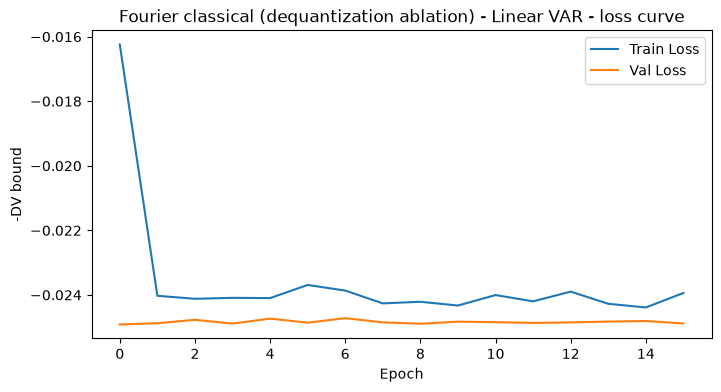

KIEM TRA TRUOC KHI DI TIEP: final_val_loss PHAI la so am co nghia (vd -0.02, khong phai ~0.0000) va readout_weight_norm PHAI khac 0 ro (>0.05). Neu ca 2 dieu kien tren KHONG dung, mo hinh VAN sup do - dung lai bao Claude.


In [4]:
plt.figure(figsize=(8, 4))
plt.plot(hist_fourier_linear['train_loss_history'], label='Train Loss')
plt.plot(hist_fourier_linear['val_loss_history'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('-DV bound'); plt.legend()
plt.title('Fourier classical (dequantization ablation) - Linear VAR - loss curve')
out_dir = BASE / 'results' / 'figures'; out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'phase_p2_fourier_linear_loss.png', dpi=100)
plt.show()
print('KIEM TRA TRUOC KHI DI TIEP: final_val_loss PHAI la so am co nghia (vd -0.02,',
      'khong phai ~0.0000) va readout_weight_norm PHAI khac 0 ro (>0.05). Neu ca 2',
      'dieu kien tren KHONG dung, mo hinh VAN sup do - dung lai bao Claude.')

In [5]:
raw_fourier_linear = evaluate_estimators_on_grid(
    {'Fourier_classical': est_fourier_linear}, test_windows_linear, progress=True)
summary_fourier_linear = summarize_grid(raw_fourier_linear)
summary_fourier_linear.head()

Evaluating windows: 100%|██████████| 18000/18000 [04:23<00:00, 68.26it/s]


,config_name,coupling_c,noise_std,n_samples,estimator,n_valid,n_failed,bias,variance,mse,ci_low,ci_high
0,c_0.0_noise_0.3,0.0,0.3,10,Fourier_classical,200,0,-0.023817,0.001612,0.002171,-0.029381,-0.018254
1,c_0.0_noise_0.3,0.0,0.3,20,Fourier_classical,200,0,-0.039709,0.001424,0.002994,-0.044939,-0.034479
2,c_0.0_noise_0.3,0.0,0.3,30,Fourier_classical,200,0,-0.041076,0.000920,0.002603,-0.045279,-0.036872
3,c_0.0_noise_0.3,0.0,0.3,50,Fourier_classical,200,0,-0.046232,0.000699,0.002833,-0.049897,-0.042568
4,c_0.0_noise_0.3,0.0,0.3,100,Fourier_classical,200,0,-0.048297,0.000331,0.002662,-0.050819,-0.045776


## 2. Dữ liệu phi tuyến (periodic coupling) — train + đánh giá

In [6]:
corpus_dir_periodic = BASE / 'data' / 'interim' / 'synthetic_corpus_periodic'
train_windows_p = load_corpus(str(corpus_dir_periodic / 'train.npz'))
val_windows_p = load_corpus(str(corpus_dir_periodic / 'val.npz'))
test_windows_periodic = load_corpus(str(corpus_dir_periodic / 'test.npz'))
print(f'Periodic: train={len(train_windows_p)}, val={len(val_windows_p)}, test={len(test_windows_periodic)}')

Periodic: train=8160, val=1440, test=7200


In [7]:
start = time.time()
est_fourier_periodic, hist_fourier_periodic = train_amortized(
    train_windows_p, val_windows_p, config_fourier,
    model_factory=lambda: FourierFeatureStatisticsNetwork(N_HARMONICS, N_DIRECTIONS),
)
print(f'Time: {time.time()-start:.1f}s, epochs run: {len(hist_fourier_periodic["train_loss_history"])}, '
      f'final_val_loss={hist_fourier_periodic["final_val_loss"]:.5f}, '
      f'readout_weight_norm={est_fourier_periodic.model.readout.weight.norm().item():.4f}')

Time: 1060.1s, epochs run: 29, final_val_loss=-0.29156, readout_weight_norm=1.2373


In [8]:
raw_fourier_periodic = evaluate_estimators_on_grid(
    {'Fourier_classical': est_fourier_periodic}, test_windows_periodic, progress=True)
summary_fourier_periodic = summarize_grid(raw_fourier_periodic)
summary_fourier_periodic.head()

Evaluating windows: 100%|██████████| 7200/7200 [7:01:48<00:00,  3.52s/it]      


,config_name,coupling_c,noise_std,n_samples,estimator,n_valid,n_failed,bias,variance,mse,ci_low,ci_high
0,periodic_k_0.0_noise_0.1,0.0,0.1,10,Fourier_classical,150,0,-0.551575,0.083326,0.387005,-0.597771,-0.505380
1,periodic_k_0.0_noise_0.1,0.0,0.1,20,Fourier_classical,150,0,-0.604487,0.110409,0.475077,-0.657662,-0.551311
2,periodic_k_0.0_noise_0.1,0.0,0.1,30,Fourier_classical,150,0,-0.633951,0.110918,0.512072,-0.687249,-0.580653
3,periodic_k_0.0_noise_0.1,0.0,0.1,50,Fourier_classical,150,0,-0.630022,0.102982,0.499224,-0.681378,-0.578666
4,periodic_k_0.0_noise_0.1,0.0,0.1,100,Fourier_classical,150,0,-0.663221,0.079433,0.518766,-0.708325,-0.618118


## 3. Gộp với KSG/Amortized đã có sẵn (KHÔNG tính lại) + so sánh

In [9]:
tables_dir = BASE / 'results' / 'tables'

df_linear_existing = pd.read_csv(tables_dir / 'phase_r_grid_summary.csv')
df_linear_existing = df_linear_existing[df_linear_existing['estimator'].isin(['KSG', 'Amortized'])].copy()
summary_fourier_linear['estimator'] = 'Fourier_classical'
df_linear = pd.concat([df_linear_existing, summary_fourier_linear], ignore_index=True)
df_linear['dataset'] = 'Linear VAR'

df_periodic_existing = pd.read_csv(tables_dir / 'phase_r2_periodic_grid_summary.csv')
df_periodic_existing = df_periodic_existing[df_periodic_existing['estimator'].isin(['KSG', 'Amortized'])].copy()
summary_fourier_periodic['estimator'] = 'Fourier_classical'
df_periodic = pd.concat([df_periodic_existing, summary_fourier_periodic], ignore_index=True)
df_periodic['dataset'] = 'Periodic Coupling'

df_all = pd.concat([df_linear, df_periodic], ignore_index=True)
df_all.to_csv(tables_dir / 'phase_p2_dequantization_summary.csv', index=False)
print(f'Da luu {len(df_all)} dong -> phase_p2_dequantization_summary.csv')

Da luu 414 dong -> phase_p2_dequantization_summary.csv


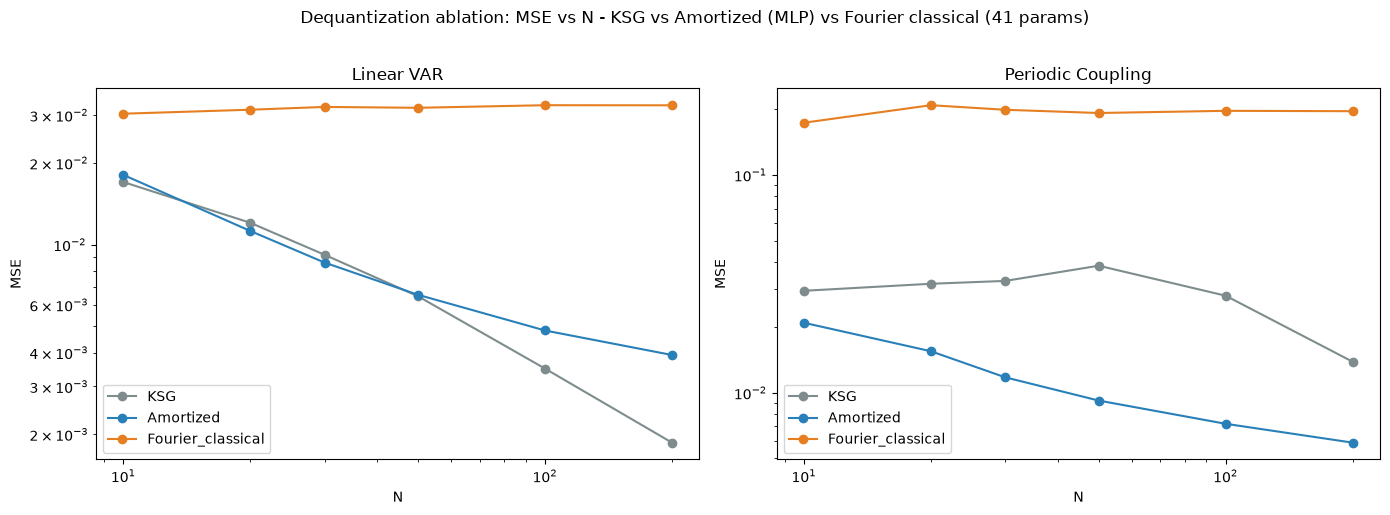

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'KSG': '#7f8c8d', 'Amortized': '#2980b9', 'Fourier_classical': '#e67e22'}
for ax, ds in zip(axes, ['Linear VAR', 'Periodic Coupling']):
    sub = df_all[df_all['dataset'] == ds]
    for est, color in colors.items():
        g = sub[sub['estimator'] == est].groupby('n_samples')['mse'].mean().reset_index()
        ax.plot(g['n_samples'], g['mse'], marker='o', label=est, color=color)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('N'); ax.set_ylabel('MSE'); ax.set_title(ds); ax.legend()
fig.suptitle('Dequantization ablation: MSE vs N - KSG vs Amortized (MLP) vs Fourier classical (41 params)', y=1.02)
plt.tight_layout()
plt.savefig(out_dir / 'phase_p2_dequantization_mse.png', dpi=110, bbox_inches='tight')
plt.show()

## 4. Kết luận (tính từ số liệu, không đoán trước)

In [11]:
for ds in ['Linear VAR', 'Periodic Coupling']:
    sub = df_all[df_all['dataset'] == ds]
    piv = sub.groupby(['n_samples', 'estimator'])['mse'].mean().unstack()
    n_fourier_beats_amortized = int((piv['Fourier_classical'] < piv['Amortized']).sum())
    n_total = len(piv)
    mse_range_fourier = piv['Fourier_classical'].max() - piv['Fourier_classical'].min()
    print(f'=== {ds} ===')
    print(piv)
    print(f'-> Fourier_classical thang Amortized (MLP) ve MSE o {n_fourier_beats_amortized}/{n_total} gia tri N.')
    print(f'-> Do bien thien MSE cua Fourier_classical qua cac N: {mse_range_fourier:.6f} '
          f'({"CANH BAO: qua nho, co the van con sup do" if mse_range_fourier < 1e-5 else "OK, khac nhau co nghia theo N"})')
    print()

print('Doc ket qua theo docs/NHIP2_GUIDE.md muc 1:')
print('- Neu KHONG con canh bao sup do o tren: so sanh MSE that su co nghia.')
print('  + Fourier_classical thang/ngang Amortized -> tin hieu tot co the den tu DANG')
print('    HAM Fourier, chua chac can luong tu thuc.')
print('  + Fourier_classical thua ro -> can luong tu thuc (entanglement) manh hon.')
print('- Neu VAN con canh bao sup do: bao Claude, co the can them n_directions/n_harmonics.')

=== Linear VAR ===
estimator  Amortized  Fourier_classical       KSG
n_samples                                        
10          0.018054           0.030346  0.016995
20          0.011221           0.031394  0.012027
30          0.008582           0.032140  0.009169
50          0.006527           0.031909  0.006445
100         0.004823           0.032616  0.003490
200         0.003917           0.032590  0.001862
-> Fourier_classical thang Amortized (MLP) ve MSE o 0/6 gia tri N.
-> Do bien thien MSE cua Fourier_classical qua cac N: 0.002269 (OK, khac nhau co nghia theo N)

=== Periodic Coupling ===
estimator  Amortized  Fourier_classical       KSG
n_samples                                        
10          0.020952           0.173689  0.029384
20          0.015506           0.209013  0.031648
30          0.011773           0.199158  0.032616
50          0.009206           0.192476  0.038296
100         0.007202           0.196974  0.027897
200         0.005901           0.196196  0